In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd



Function to clean data

In [2]:
def clean_dataframe(df):
    df = df.copy()

    # ---- 1. Drop unnecessary columns (if they exist) ----
    columns_to_drop = ["job_url", "company_url", "benefit", "country", "benifts"]
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

    # ---- 2. Standardize column names ----
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

    # ---- 3. Text cleaning ----
    emoji_pattern = re.compile(r'[\U00010000-\U0010ffff]')

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].apply(
            lambda x: (
                emoji_pattern.sub('', str(x))        # remove emojis
                .replace('\n', ' ')                  # remove newline characters
                .strip()
                .lower()                             # convert to lowercase
            ) if isinstance(x, str) else x
        )

        # remove extra spaces
        df[col] = df[col].str.replace(r"\s+", " ", regex=True)

        # remove special characters except -, /
        df[col] = df[col].str.replace(r"[^\w\s\-\/]", "", regex=True)
    
    return df
    

In [3]:
def normalize_location(loc):
    if pd.isna(loc):
        return loc
    
    loc = str(loc).lower()
    
    if "madrid" in loc:
        return "Madrid"
    elif "barcelona" in loc:
        return "Barcelona"
    else:
        return loc.title()

In [4]:
def remove_job_description_duplicates(df):
    df = df.copy()
    
    # Find duplicates (only the repeated ones, not the first occurrence)
    duplicate_count = df.duplicated(subset=["job_description"]).sum()
    print(f"Found {duplicate_count} duplicate rows.")
    
    # Keep first occurrence, remove the rest
    df_clean = df.drop_duplicates(subset=["job_description"], keep="first")
    
    print(f"New dataframe shape: {df_clean.shape}")
    
    return df_clean

In [5]:
def plot_work_mode_multilingual(df):
    df = df.copy()
    
    remote_keywords = [
        "remote", "full remote", "work from home",
        "remoto", "trabajo remoto", "en remoto",
        "teletrabajo", "a distancia", "desde casa",
        "home office"
    ]
    
    hybrid_keywords = [
        "hybrid", "hybrid model",
        "híbrido", "hibrido",
        "modalidad híbrida", "modalidad hibrida",
        "modelo híbrido", "modelo hibrido",
        "mixto", "modalidad mixta"
    ]
    
    onsite_keywords = [
        "onsite", "on site",
        "presencial", "trabajo presencial",
        "modalidad presencial",
        "en oficina", "en sede"
    ]
    
    def classify_mode(text):
        if pd.isna(text):
            return "unspecified"
        
        text = str(text).lower()
        
        # Priority: hybrid > remote > onsite
        if any(keyword in text for keyword in hybrid_keywords):
            return "hybrid"
        elif any(keyword in text for keyword in remote_keywords):
            return "remote"
        elif any(keyword in text for keyword in onsite_keywords):
            return "onsite"
        else:
            return "unspecified"
    
    df["work_mode"] = df["job_description"].apply(classify_mode)
    
    counts = df["work_mode"].value_counts()
    
    plt.figure()
    counts.plot(kind="bar")
    plt.xlabel("Work Mode")
    plt.ylabel("Number of Jobs")
    plt.title("Work Mode Distribution (Multilingual)")
    plt.xticks(rotation=0)
    plt.show()
    
    return df
    

In [6]:
def plot_language_distribution(df):
    df = df.copy()
    
    spanish_markers = [
        " que ", " de ", " en ", " para ", " con ",
        " experiencia ", " equipo ", " datos ",
        " desarrollo ", " habilidades "
    ]
    
    english_markers = [
        " the ", " and ", " with ", " for ", " to ",
        " experience ", " team ", " data ",
        " development ", " skills "
    ]
    
    def classify_language(text):
        if pd.isna(text):
            return "other"
        
        text = " " + str(text).lower() + " "
        
        spanish_score = sum(marker in text for marker in spanish_markers)
        english_score = sum(marker in text for marker in english_markers)
        
        if spanish_score > english_score and spanish_score > 0:
            return "spanish"
        elif english_score > spanish_score and english_score > 0:
            return "english"
        else:
            return "other"
    
    df["language"] = df["job_description"].apply(classify_language)
    
    counts = df["language"].value_counts()
    
    plt.figure()
    counts.plot(kind="bar")
    plt.xlabel("Language")
    plt.ylabel("Number of Jobs")
    plt.title("Language Distribution of Job Descriptions")
    plt.xticks(rotation=0)
    plt.show()
    
   

# EDA data scientist Jonior  

In [7]:
data_scientist_j = pd.read_csv("scientist_jun.csv")


data cleaning: 

In [8]:
clean_dataframe(data_scientist_j)

,job_title,company_name,location,posted,company_description,job_description
0,científico/a de datos data scientist científic...,quental,barcelona catalonia spain,2 weeks ago,te gustaría participar en un gran proyecto de ...,te gustaría participar en un gran proyecto de ...
1,data scientist,sabadell consumer finance,sant cugat del vallès catalonia spain,1 day ago,qué estamos buscando actualmente nos encontram...,qué estamos buscando actualmente nos encontram...
2,data scientist,linde material handling iberica sa,barcelona catalonia spain,2 weeks ago,linde material handling is among the world lea...,linde material handling is among the world lea...
3,data scientist - 100 teletrabajo,nunegal consulting,spain,1 week ago,tienes experiencia como data scientist te inte...,tienes experiencia como data scientist te inte...
4,machine learning engineer / data engineer,tendam,greater madrid metropolitan area,2 weeks ago,machine learning engineer / data engineer at t...,machine learning engineer / data engineer at t...
...,...,...,...,...,...,...
65,únete a un equipo dinámico envía tu cv,grupo vihotec,murcia región de murcia spain,1 week ago,ubicación varias ubicaciones disponibles jorna...,ubicación varias ubicaciones disponibles jorna...
66,join us comunidad valenciana,the fitzgerald burger company,torrent valencian community spain,NaN,descripción en the fitzgerald nos flipa dar el...,descripción en the fitzgerald nos flipa dar el...
67,entrenador,degood,granada andalusia spain,5 days ago,entrenar bien es sobre todo rodearse bienen de...,entrenar bien es sobre todo rodearse bienen de...
68,mozos de carga y descarga almacén y/o mercado ...,ferrocarrils generalitat valenciana,alicante valencian community spain,3 days ago,requisitospersona joven menor de 30 años e ins...,requisitospersona joven menor de 30 años e ins...


In [9]:
data_scientist_j = remove_job_description_duplicates(data_scientist_j)

Found 8 duplicate rows.
New dataframe shape: (62, 10)


Exploratory Data Analysis

In [10]:
data_scientist_j["location"].value_counts().head(10)

location
Madrid, Community of Madrid, Spain         15
Spain                                      15
Barcelona, Catalonia, Spain                10
Greater Madrid Metropolitan Area            5
Sant Cugat del Vallès, Catalonia, Spain     3
Valencia, Valencian Community, Spain        2
Las Palmas, Canary Islands, Spain           1
Greater Barcelona Metropolitan Area         1
Alcobendas, Community of Madrid, Spain      1
Paterna, Valencian Community, Spain         1
Name: count, dtype: int64

In [11]:
data_scientist_j["posted"].value_counts()

posted
2 weeks ago    16
1 week ago     14
1 day ago       7
5 days ago      4
3 weeks ago     3
4 days ago      3
6 days ago      3
3 days ago      3
Name: count, dtype: int64

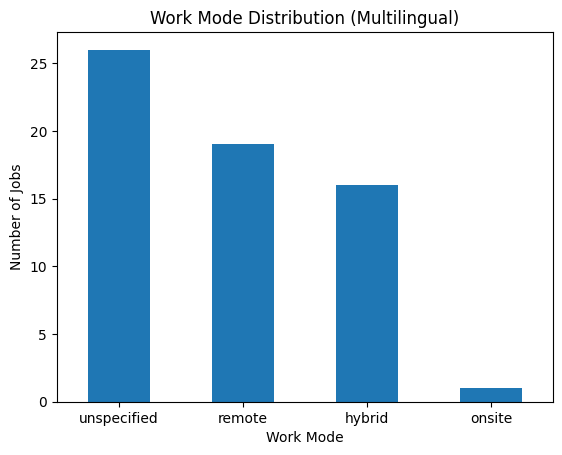

In [12]:
data_scientist_j = plot_work_mode_multilingual(data_scientist_j)

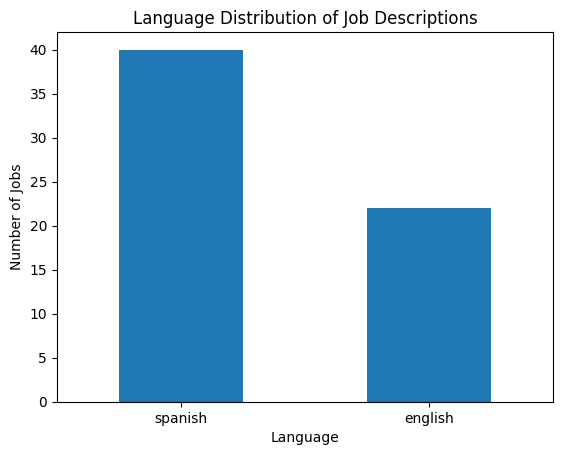

In [13]:
plot_language_distribution(data_scientist_j)

# EDA Junior Data Analyst 

In [14]:
data_analyst_j = pd.read_csv("analyst_jun.csv")

In [15]:
data_analyst_j.shape

(70, 10)

Clean Data: 

In [16]:
data_analyst_j= clean_dataframe(data_analyst_j)

In [17]:
data_analyst_j= remove_job_description_duplicates(data_analyst_j)

Found 5 duplicate rows.
New dataframe shape: (65, 6)


Exploratory Data Analysis

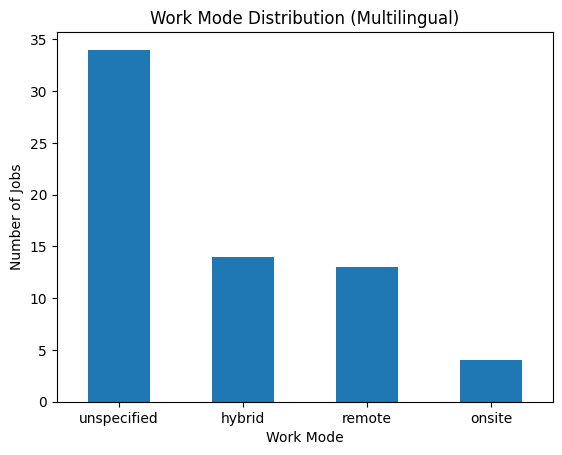

In [18]:
data_analyst_j = plot_work_mode_multilingual(data_analyst_j)

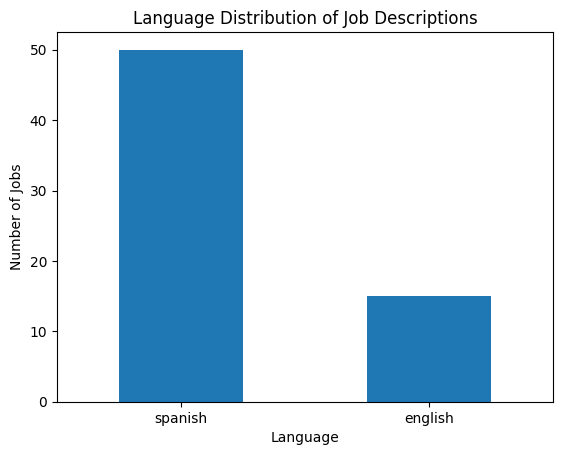

In [19]:
plot_language_distribution(data_analyst_j)

# EDA Senior data scientist 

In [20]:
data_scientist_s = pd.read_csv("scientist_sen.csv")

clean data:

In [21]:
data_scientist_s.shape

(70, 10)

In [22]:
data_scientist_s = clean_dataframe(data_scientist_s)    

In [23]:
data_scientist_s = remove_job_description_duplicates(data_scientist_s)

Found 15 duplicate rows.
New dataframe shape: (55, 6)


Exploratory Data Analysis

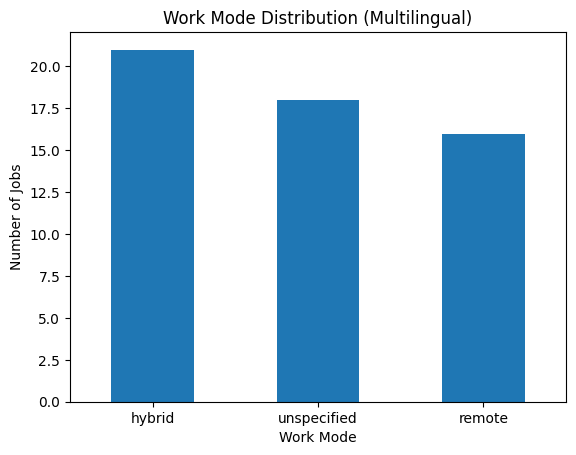

In [24]:
data_scientist_s =plot_work_mode_multilingual(data_scientist_s)

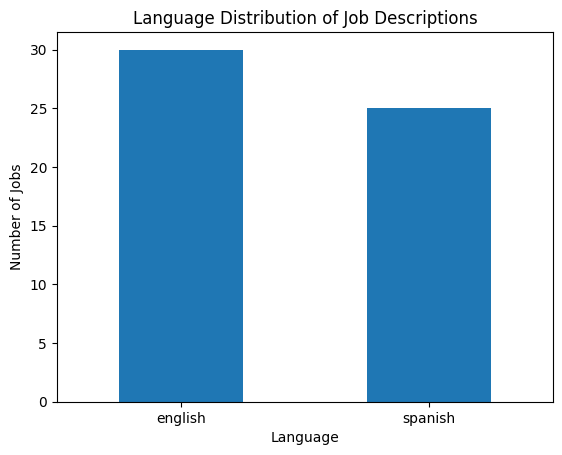

In [25]:
plot_language_distribution(data_scientist_s)

# EDA senior data analyst 

In [26]:
data_analyst_s = pd.read_csv("analyst_sen.csv")

Clean data: 

In [27]:
data_analyst_s = clean_dataframe(data_analyst_s)

In [28]:
data_analyst_s = remove_job_description_duplicates(data_analyst_s)

Found 10 duplicate rows.
New dataframe shape: (59, 6)


Exploratory Data Analysis:

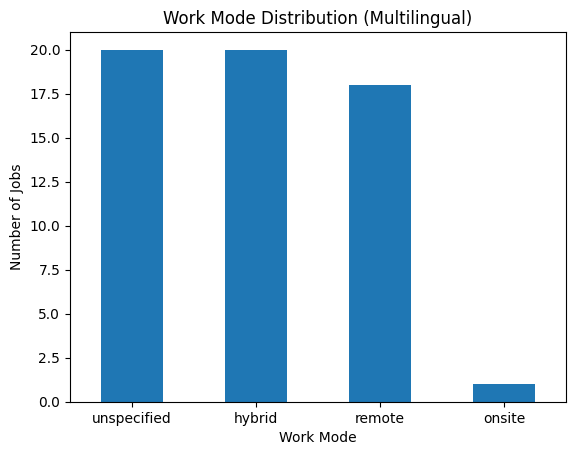

In [29]:
data_analyst_s = plot_work_mode_multilingual(data_analyst_s)

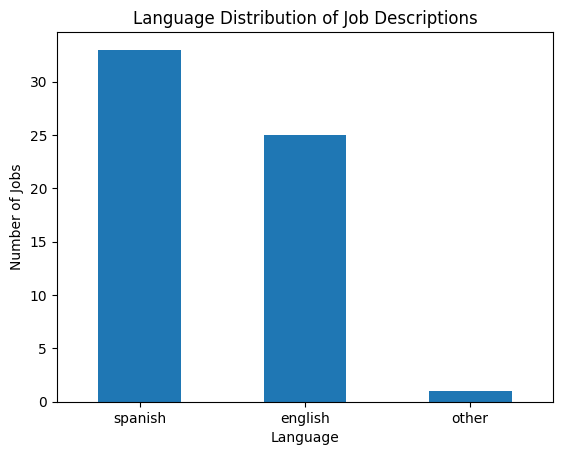

In [30]:
plot_language_distribution(data_analyst_s)

In [31]:
data_analyst_s

,job_title,company_name,location,posted,company_description,job_description,work_mode
0,analista de datos remoto,plexus tech,spain,4 days ago,somos plexus tech una compañía tecnológica esp...,somos plexus tech una compañía tecnológica esp...,remote
1,data analyst,remynd,madrid community of madrid spain,4 days ago,data analyst madrid contrato indefinido mínim...,data analyst madrid contrato indefinido mínim...,unspecified
2,data modeller remote from spain,ust españa latam,spain,4 days ago,we are still looking for the very top talentan...,we are still looking for the very top talentan...,remote
3,analista de datos google looker 100 teletrabajo,entelgy,greater madrid metropolitan area,4 days ago,hola bienvenido a nuestras ofertas vamos a co...,hola bienvenido a nuestras ofertas vamos a co...,remote
4,marketing data analyst,e-frontiers,madrid community of madrid spain,4 days ago,desde e-frontiers estamos buscando un/a senior...,desde e-frontiers estamos buscando un/a senior...,unspecified
5,senior data insight business analyst,talent insights,viladecans catalonia spain,3 days ago,talent insights somos una agencia de networkin...,talent insights somos una agencia de networkin...,unspecified
6,data analyst,cognizant netcentric,barcelona catalonia spain,2 weeks ago,we are looking for a data analyst to support f...,we are looking for a data analyst to support f...,unspecified
7,data analyst,mca españa,madrid community of madrid spain,1 week ago,únete a mca oportunidad data analyst en entor...,únete a mca oportunidad data analyst en entor...,hybrid
8,data analyst power bi,intelequia,canary islands spain,3 weeks ago,quieres un desafío profesional en una consulto...,quieres un desafío profesional en una consulto...,hybrid
9,data analyst,migx ag,barcelona catalonia spain,1 week ago,about migx migx is a global consulting company...,about migx migx is a global consulting company...,hybrid


compare jobs 

In [32]:
def add_role_column(df, role_name):
    df = df.copy()
    df["role"] = role_name
    return df

In [33]:
df_analyst_jr = add_role_column(data_analyst_j, "Data Analyst Junior")
df_analyst_sr = add_role_column(data_analyst_s, "Data Analyst Senior")
df_scientist_jr = add_role_column(data_scientist_j, "Data Scientist Junior")
df_scientist_sr = add_role_column(data_scientist_s, "Data Scientist Senior")

In [34]:
def merge_job_dfs(dfs):
    return pd.concat(dfs, ignore_index=True)

In [35]:
df = merge_job_dfs([
    df_analyst_jr,
    df_analyst_sr,
    df_scientist_jr,
    df_scientist_sr
])

In [36]:
df

,job_title,company_name,location,posted,company_description,job_description,work_mode,role,country,company_url,benefit,job_url
0,data analyst junior madrid,securitas seguridad españa,madrid community of madrid spain,1 week ago,te motiva impulsar la toma de decisiones a tra...,te motiva impulsar la toma de decisiones a tra...,unspecified,Data Analyst Junior,NaN,NaN,NaN,NaN
1,data analyst-engineer,ma montreal associates,madrid community of madrid spain,4 days ago,im currently looking for a data analyst who kn...,im currently looking for a data analyst who kn...,unspecified,Data Analyst Junior,NaN,NaN,NaN,NaN
2,finance data analyst sector banca,optimissa,greater madrid metropolitan area,4 days ago,en optimissa consultora especializada en serv...,en optimissa consultora especializada en serv...,hybrid,Data Analyst Junior,NaN,NaN,NaN,NaN
3,analista de datos,optimissa,spain,3 days ago,en optimissa tenemos claro que el éxito de nue...,en optimissa tenemos claro que el éxito de nue...,remote,Data Analyst Junior,NaN,NaN,NaN,NaN
4,data analyst para información de gestión,banco sabadell,greater barcelona metropolitan area,2 weeks ago,somos grupo banco sabadell grupo banco sabadel...,somos grupo banco sabadell grupo banco sabadel...,unspecified,Data Analyst Junior,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
236,medical science liaison spain,pharmanovia,greater madrid metropolitan area,1 week ago,field role based in spain salary competitive ...,field role based in spain salary competitive ...,hybrid,Data Scientist Senior,NaN,NaN,NaN,NaN
237,subdirector/a hoteles elba,hoteles elba hotels resorts,rota andalusia spain,4 days ago,en hoteles elba buscamos profesionales que qui...,en hoteles elba buscamos profesionales que qui...,unspecified,Data Scientist Senior,NaN,NaN,NaN,NaN
238,talent acquisition,red bull,madrid community of madrid spain,4 days ago,mission the talent acquisition will be respons...,mission the talent acquisition will be respons...,unspecified,Data Scientist Senior,NaN,NaN,NaN,NaN
239,senior associate in aml/kyc,fundcraft,girona catalonia spain,4 weeks ago,as a senior associate in aml/kyc you are an in...,as a senior associate in aml/kyc you are an in...,unspecified,Data Scientist Senior,NaN,NaN,NaN,NaN


merged the 4 dataphamres toghter.

In [37]:
def plot_work_mode_by_role(df):

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x="work_mode",
        hue="role"
    )

    plt.title("Work Mode Distribution by Role")
    plt.xticks(rotation=45)

    plt.show()

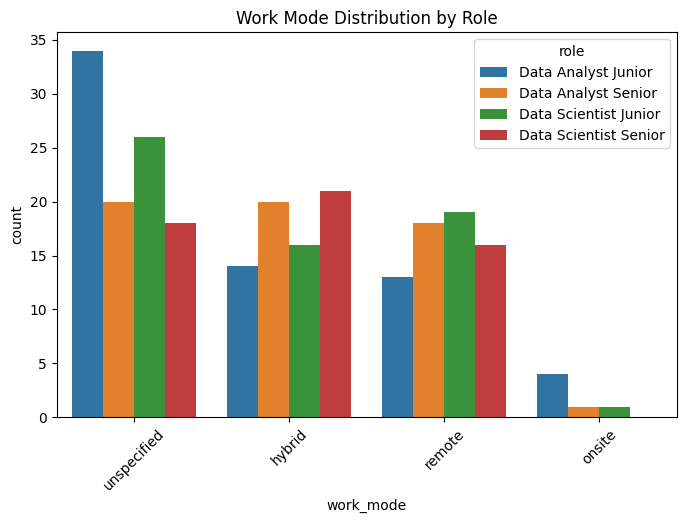

In [38]:
plot_work_mode_by_role(df)

In [39]:
def location_by_role(df):

    top_locations = df["location"].value_counts().head().index

    filtered = df[df["location"].isin(top_locations)]

    plt.figure(figsize=(10,6))

    sns.countplot(
        data=filtered,
        y="location",
        hue="role"
    )

    plt.title("Top Locations by Role")

    plt.show()

In [40]:
def normalize_location(df):

    def clean(loc):
        if pd.isna(loc):
            return loc

        loc = str(loc).lower()

        if "madrid" in loc:
            return "Madrid"
        elif "barcelona" in loc:
            return "Barcelona"
        else:
            return loc.title()

    df["location"] = df["location"].apply(clean)

    return df

In [41]:
df = normalize_location(df)

In [42]:
df

,job_title,company_name,location,posted,company_description,job_description,work_mode,role,country,company_url,benefit,job_url
0,data analyst junior madrid,securitas seguridad españa,Madrid,1 week ago,te motiva impulsar la toma de decisiones a tra...,te motiva impulsar la toma de decisiones a tra...,unspecified,Data Analyst Junior,NaN,NaN,NaN,NaN
1,data analyst-engineer,ma montreal associates,Madrid,4 days ago,im currently looking for a data analyst who kn...,im currently looking for a data analyst who kn...,unspecified,Data Analyst Junior,NaN,NaN,NaN,NaN
2,finance data analyst sector banca,optimissa,Madrid,4 days ago,en optimissa consultora especializada en serv...,en optimissa consultora especializada en serv...,hybrid,Data Analyst Junior,NaN,NaN,NaN,NaN
3,analista de datos,optimissa,Spain,3 days ago,en optimissa tenemos claro que el éxito de nue...,en optimissa tenemos claro que el éxito de nue...,remote,Data Analyst Junior,NaN,NaN,NaN,NaN
4,data analyst para información de gestión,banco sabadell,Barcelona,2 weeks ago,somos grupo banco sabadell grupo banco sabadel...,somos grupo banco sabadell grupo banco sabadel...,unspecified,Data Analyst Junior,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
236,medical science liaison spain,pharmanovia,Madrid,1 week ago,field role based in spain salary competitive ...,field role based in spain salary competitive ...,hybrid,Data Scientist Senior,NaN,NaN,NaN,NaN
237,subdirector/a hoteles elba,hoteles elba hotels resorts,Rota Andalusia Spain,4 days ago,en hoteles elba buscamos profesionales que qui...,en hoteles elba buscamos profesionales que qui...,unspecified,Data Scientist Senior,NaN,NaN,NaN,NaN
238,talent acquisition,red bull,Madrid,4 days ago,mission the talent acquisition will be respons...,mission the talent acquisition will be respons...,unspecified,Data Scientist Senior,NaN,NaN,NaN,NaN
239,senior associate in aml/kyc,fundcraft,Girona Catalonia Spain,4 weeks ago,as a senior associate in aml/kyc you are an in...,as a senior associate in aml/kyc you are an in...,unspecified,Data Scientist Senior,NaN,NaN,NaN,NaN


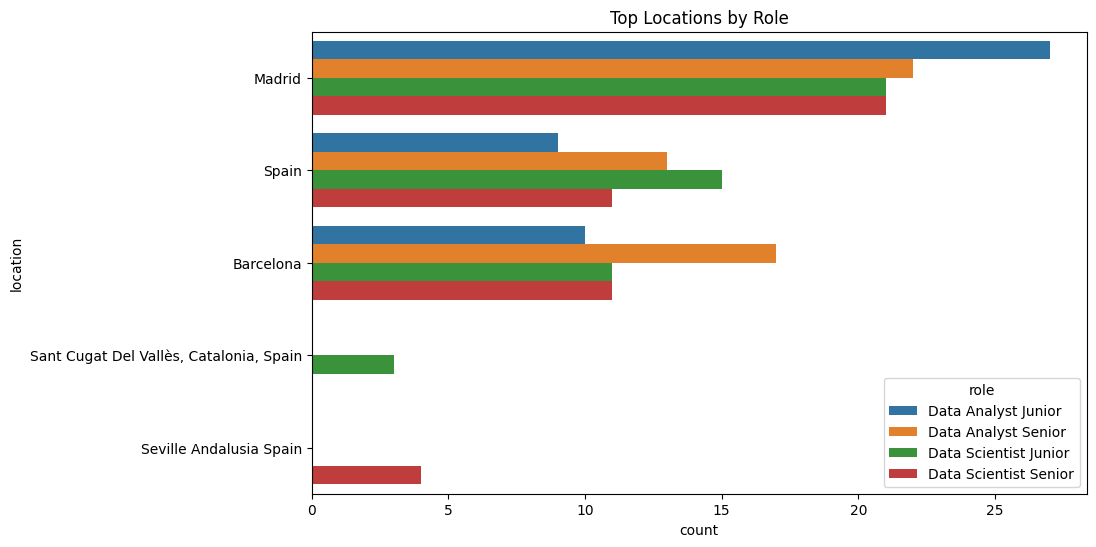

In [43]:
location_by_role(df)

seeing in what locations in spain we can find the job in. 

In [44]:
def description_length_by_role(df):

    df["desc_length"] = df["job_description"].str.split().str.len()

    plt.figure(figsize=(8,6))

    sns.boxplot(
        data=df,
        x="role",
        y="desc_length"
    )

    plt.xticks(rotation=45)
    plt.title("Description Length by Role")

    plt.show()

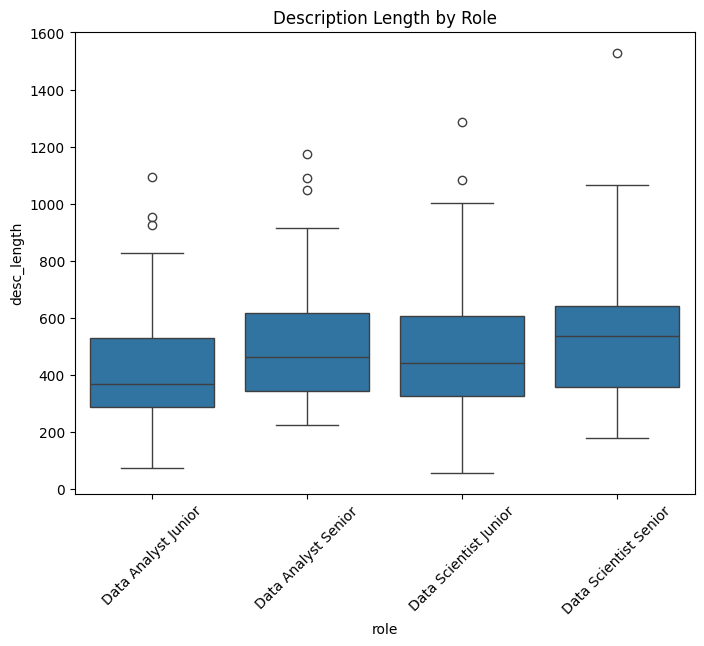

In [45]:
description_length_by_role(df)

In [46]:
skills = [
"python","sql","r","excel","tableau","power bi",
"machine learning","deep learning","spark",
"aws","azure","gcp","nlp","statistics"
]

def extract_skills(df):

    df = df.copy()

    for skill in skills:
        df[skill] = df["job_description"].str.lower().str.contains(skill)

    return df

In [47]:
df = extract_skills(df)

In [48]:
def skill_heatmap(df):

    # compute role averages
    skill_matrix = df.groupby("role")[skills].mean()

    # force numeric values
    skill_matrix = skill_matrix.apply(pd.to_numeric, errors="coerce")

    # convert to float array (guarantees seaborn compatibility)
    skill_matrix = skill_matrix.astype(float)

    plt.figure(figsize=(12,6))

    sns.heatmap(
        skill_matrix,
        annot=True,
        cmap="Blues",
        fmt=".2f"
    )

    plt.title("Skills Required by Role")
    plt.ylabel("Role")
    plt.xlabel("Skill")

    plt.show()

In [49]:
def remote_distribution(df):

    pivot = pd.crosstab(df["role"], df["work_mode"], normalize="index")

    pivot.plot(kind="bar", stacked=True, figsize=(10,6))

    plt.title("Remote Distribution by Role")
    plt.ylabel("Proportion")

    plt.show()

    return pivot

In [50]:
def company_role_heatmap(df):

    company_roles = pd.crosstab(df["company_name"], df["role"])

    top_companies = company_roles.sum(axis=1).sort_values(ascending=False).head(15)

    company_roles = company_roles.loc[top_companies.index]

    plt.figure(figsize=(10,8))

    sns.heatmap(company_roles, cmap="Blues")

    plt.title("Companies Hiring by Role")

    plt.show()

In [59]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

spanish_stopwords = {
"de","la","el","los","las","y","en","a","con","para","que","un","una",
"del","al","se","por","su","sus","como","más","pero","o"
}

stop_words = set(ENGLISH_STOP_WORDS).union(spanish_stopwords)

In [60]:


def top_words_per_role(df, n=15):

    roles = df["role"].unique()

    for role in roles:

        text = " ".join(
            df[df["role"] == role]["job_description"]
            .dropna()
            .str.lower()
        )

        words = re.findall(r'\b[a-z]+\b', text)

        words = [w for w in words if w not in stop_words and len(w) > 2]

        word_counts = pd.Series(words).value_counts().head(n)

        plt.figure(figsize=(8,5))

        sns.barplot(
            x=word_counts.values,
            y=word_counts.index
        )

        plt.title(f"Top Words - {role}")

        plt.show()

In [61]:
def run_eda(df):

    plot_work_mode_by_role(df)

    location_by_role(df)

    description_length_by_role(df)

    skill_heatmap(df)

    remote_distribution(df)

    company_role_heatmap(df)

    top_words_per_role(df)

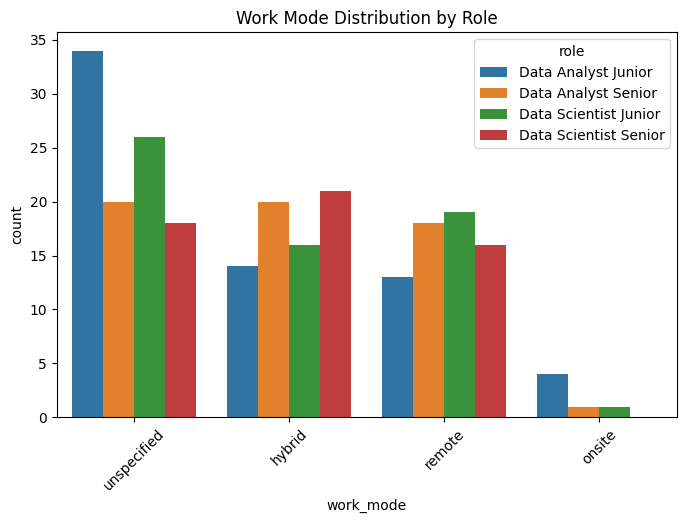

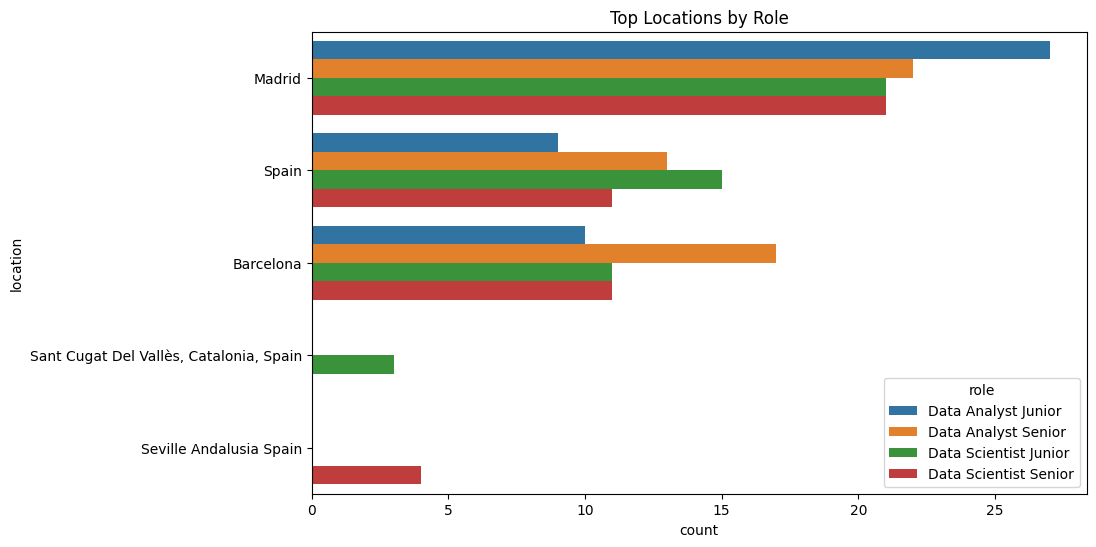

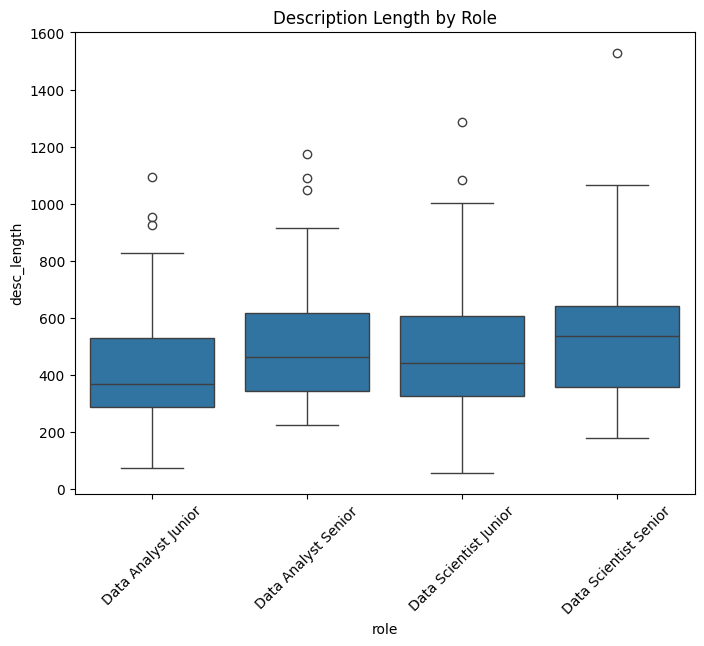

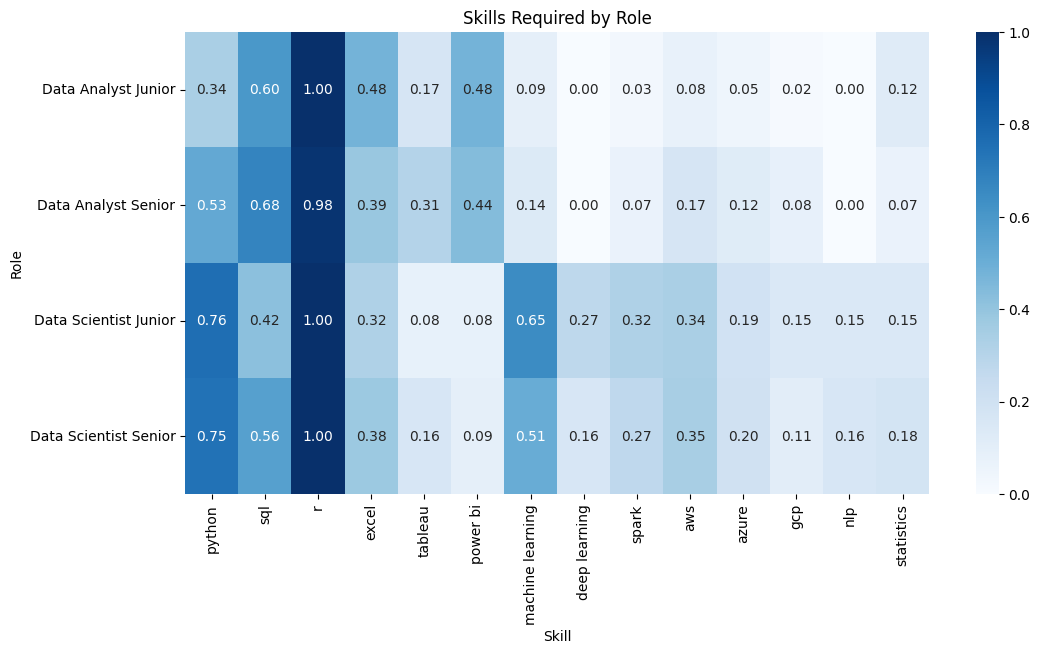

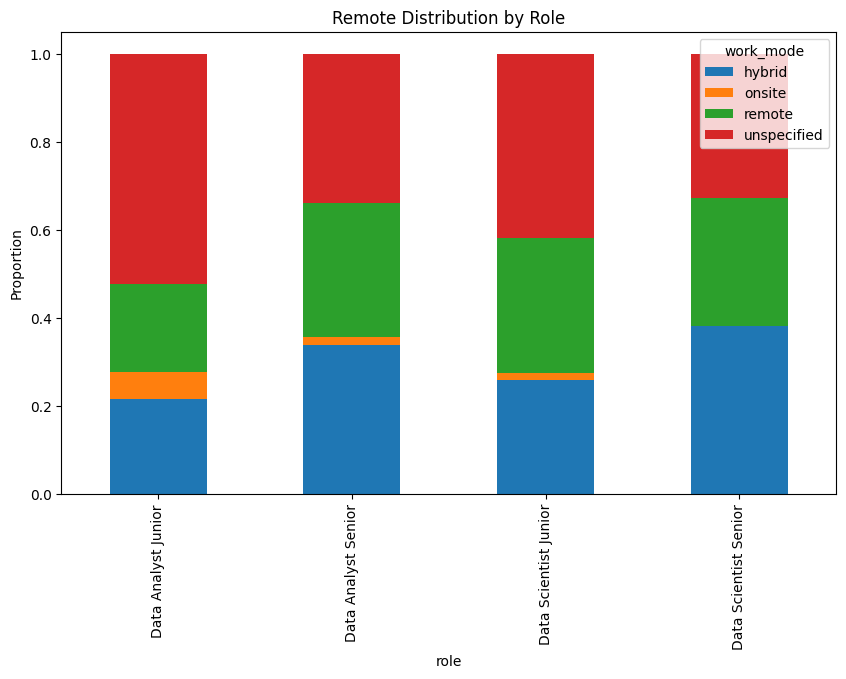

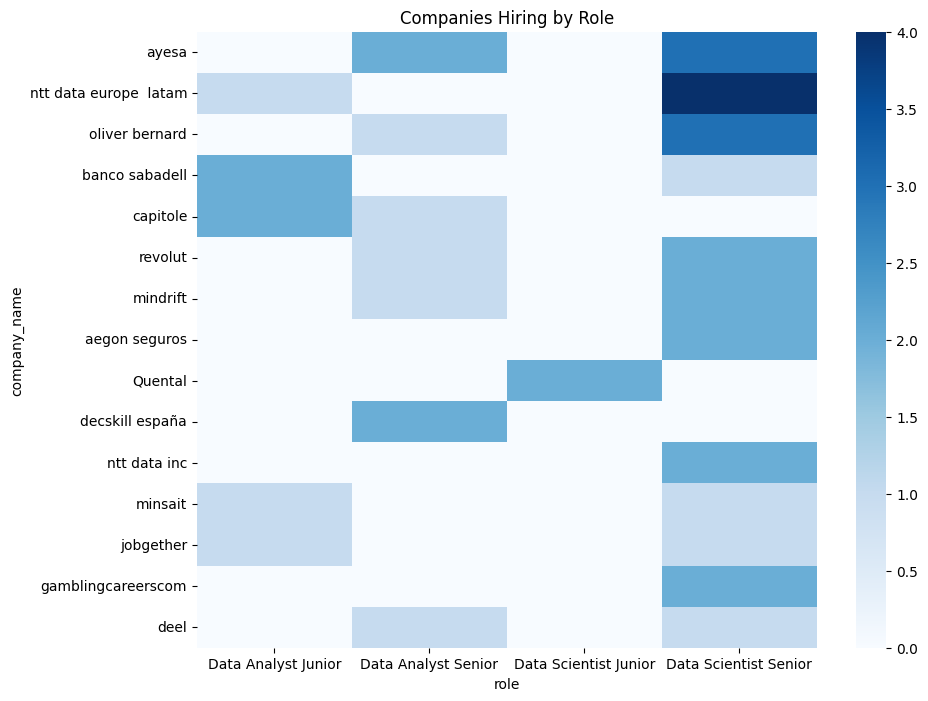

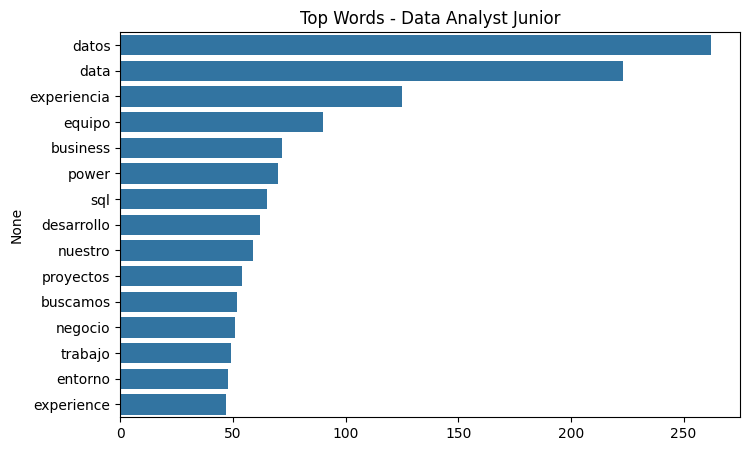

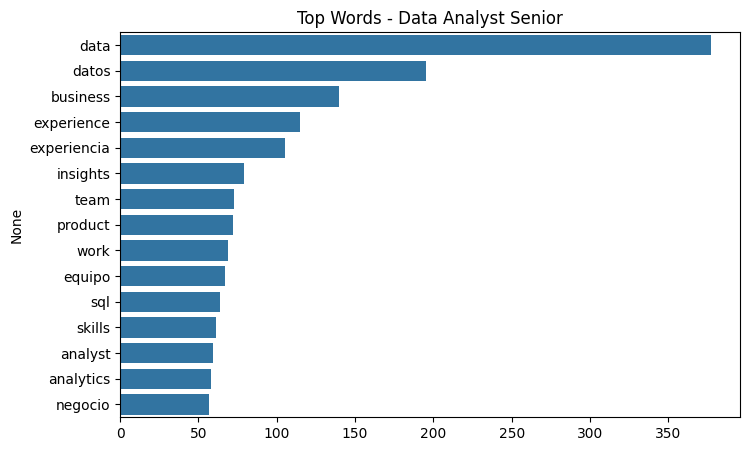

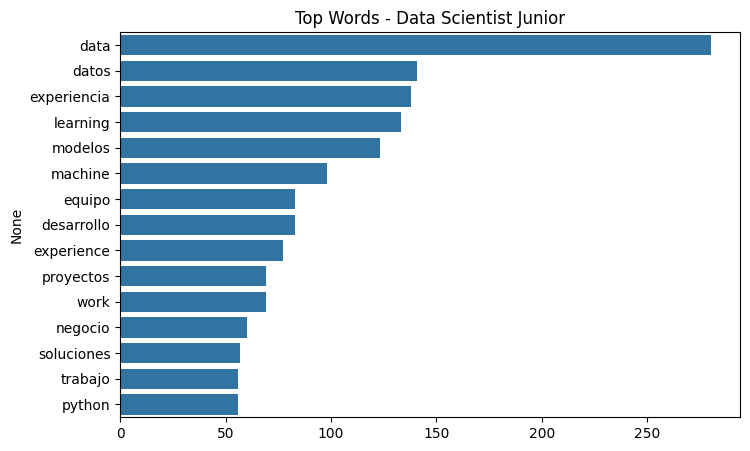

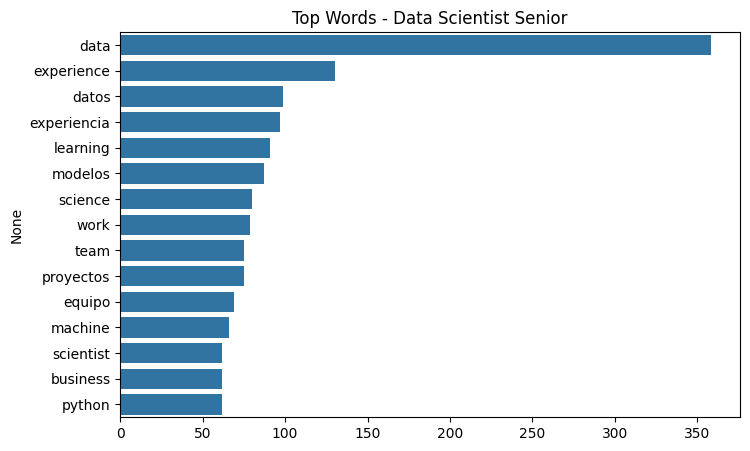

In [62]:
run_eda(df)